# **TUGAS STATISTIKA**

## Visualisasi Data Statistik ke Peta

Kelompok 4

Tema:
1. Lowongan Kerja Terdaftar di Jawa Timur
2. Indeks Ketimpangan Gender (IKG) di Jawa Barat


Sumber Data:
1. https://jatim.bps.go.id/id/statistics-table/1/MjY2OSMx/lowongan-kerja-terdaftar-menurut-kabupaten-kota-dan-jenis-kelamin-di-provinsi-jawa-timur--2022.html
2. https://jabar.bps.go.id/id/statistics-table/2/ODIzIzI=/indeks-ketimpangan-gender-ikg-.html

# 1. Tujuan Analisis

Tujuan dari project ini adalah untuk memvisualisasikan data statistik ke dalam bentuk grafik dan peta interaktif menggunakan Python dan Google Colab.

Visualisasi dilakukan untuk:
- Mengetahui persebaran lowongan kerja di Jawa Timur
- Mengetahui persebaran Indeks Ketimpangan Gender (IKG) di Jawa Barat
- Mempermudah analisis data secara geografis menggunakan heatmap

# 2. Import Library

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium

from folium.plugins import HeatMap
from google.colab import drive

# 3. Menghubungkan Google Drive

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


# 4. Load Dataset IKG Jawa Barat

In [3]:
df_jabar = pd.read_csv(
    '/content/drive/MyDrive/Statistika/jabar.csv'
)

df_jabar.head()

,Wilayah Jawa Barat,Unnamed: 1
0,NaN,Indeks Ketimpangan Gender (IKG)
1,NaN,2025
2,Provinsi Jawa Barat,0.434
3,Bogor,0.547
4,Sukabumi,0.476


# 5. Data Cleaning IKG Jawa Barat

Tahap ini dilakukan untuk:
- Menghapus metadata
- Mengubah tipe data menjadi numerik
- Menghapus data kosong
- Menyiapkan data agar siap divisualisasikan

In [4]:
# =========================
# DATA CLEANING IKG JAWA BARAT
# =========================

import pandas as pd

# Load dataset
df_ikg = pd.read_csv(
    '/content/drive/MyDrive/Statistika/jabar.csv'
)

# =========================
# MENGHAPUS METADATA
# =========================

# Menghapus 2 baris awal yang berisi metadata
df_ikg = df_ikg.iloc[2:].copy()

# =========================
# RENAME KOLOM
# =========================

df_ikg.columns = [
    'Wilayah',
    'IKG'
]

# =========================
# MENGUBAH TIPE DATA
# =========================

# Mengubah kolom IKG menjadi numerik
df_ikg['IKG'] = pd.to_numeric(
    df_ikg['IKG'],
    errors='coerce'
)

# =========================
# MENGHAPUS DATA KOSONG
# =========================

df_ikg = df_ikg.dropna(
    subset=['IKG']
)

# =========================
# MENGHAPUS BARIS PROVINSI
# =========================

df_ikg = df_ikg[
    df_ikg['Wilayah'] != 'Provinsi Jawa Barat'
]

# =========================
# MENAMPILKAN HASIL CLEANING
# =========================

df_ikg.head()

,Wilayah,IKG
3,Bogor,0.547
4,Sukabumi,0.476
5,Cianjur,0.555
6,Bandung,0.428
7,Garut,0.523


# 6. Visualisasi Grafik IKG Jawa Barat

Visualisasi grafik digunakan untuk melihat:
- wilayah dengan nilai IKG tertinggi
- wilayah dengan nilai IKG terendah
- perbandingan nilai IKG antar wilayah di Jawa Barat

/tmp/ipykernel_696/1517735755.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


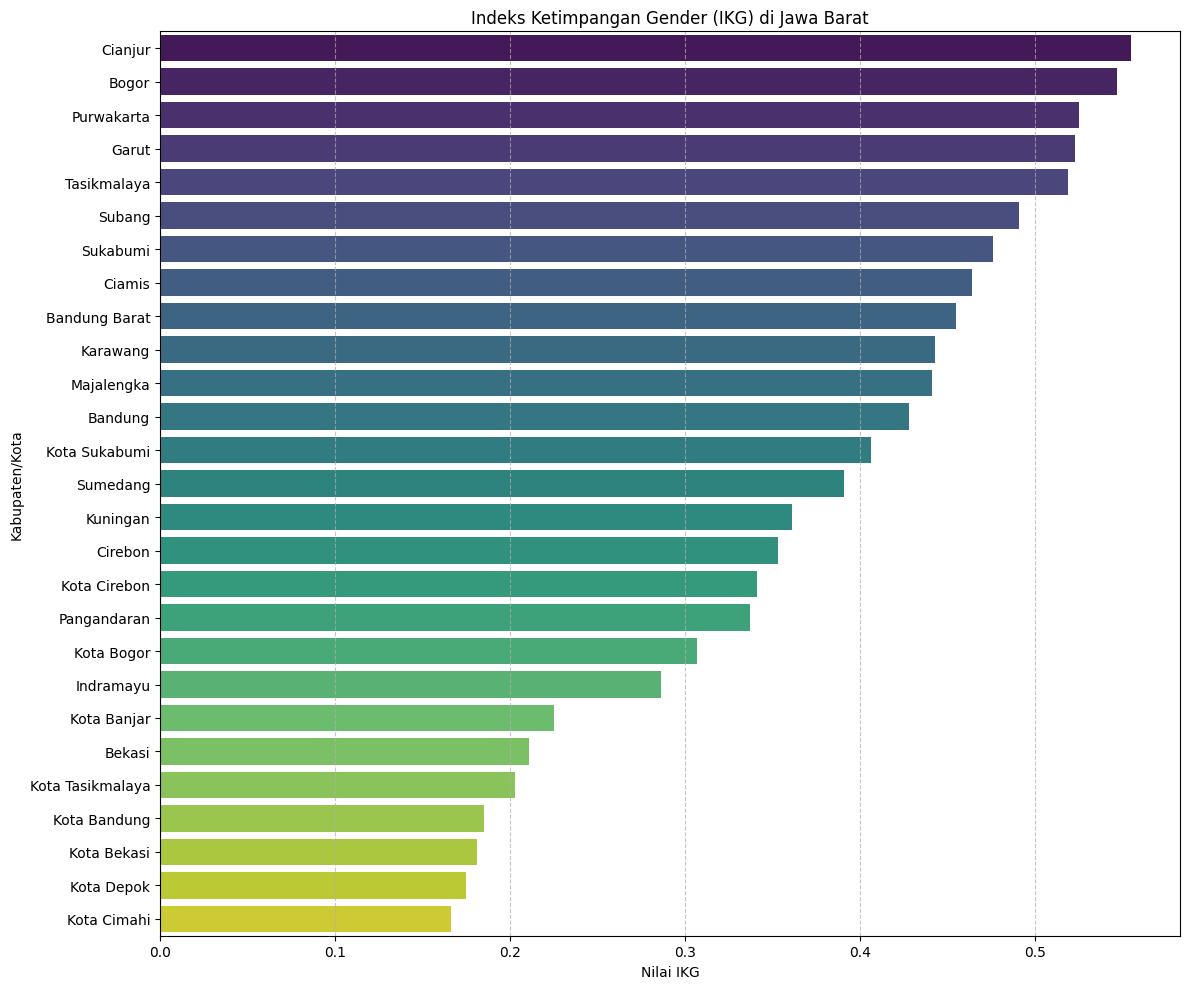

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# SORTING DATA
# =========================

# Mengurutkan data berdasarkan nilai IKG terbesar
df_ikg_sorted = df_ikg.sort_values(
    by='IKG',
    ascending=False
)

# =========================
# MEMBUAT BAR CHART
# =========================

plt.figure(figsize=(12, 10))

sns.barplot(
    data=df_ikg_sorted,
    x='IKG',
    y='Wilayah',
    palette='viridis'
)

# =========================
# MENAMBAHKAN JUDUL DAN LABEL
# =========================

plt.title(
    'Indeks Ketimpangan Gender (IKG) di Jawa Barat'
)

plt.xlabel(
    'Nilai IKG'
)

plt.ylabel(
    'Kabupaten/Kota'
)

# =========================
# MENAMBAHKAN GRID
# =========================

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.7
)

plt.tight_layout()

# =========================
# MENAMPILKAN GRAFIK
# =========================

plt.show()

# 6.1 Visualisasi IKG Berdasarkan Jenis Wilayah

Visualisasi ini digunakan untuk membandingkan nilai Indeks Ketimpangan Gender (IKG) berdasarkan jenis wilayah, yaitu Kabupaten dan Kota.

Selain itu, visualisasi ini menampilkan 10 wilayah dengan nilai IKG tertinggi di Jawa Barat agar analisis lebih terfokus dan mudah dipahami.

,Wilayah,IKG,Jenis_Wilayah
5,Cianjur,0.555,Kabupaten
3,Bogor,0.547,Kabupaten
16,Purwakarta,0.525,Kabupaten
7,Garut,0.523,Kabupaten
8,Tasikmalaya,0.519,Kabupaten
15,Subang,0.491,Kabupaten
4,Sukabumi,0.476,Kabupaten
9,Ciamis,0.464,Kabupaten
19,Bandung Barat,0.455,Kabupaten
17,Karawang,0.443,Kabupaten


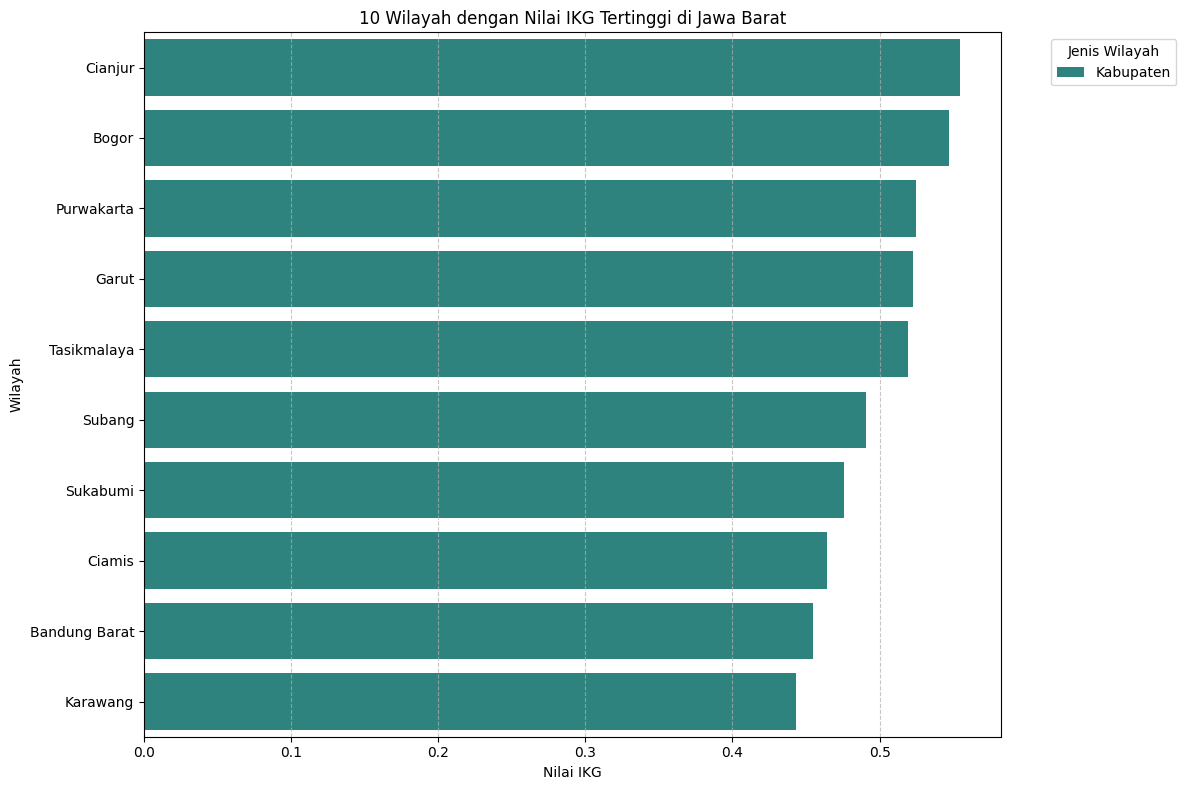

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# MENAMBAHKAN JENIS WILAYAH
# =========================

# Make a copy to avoid SettingWithCopyWarning
df_ikg_with_type = df_ikg.copy()

# Mengelompokkan wilayah menjadi Kabupaten atau Kota
df_ikg_with_type['Jenis_Wilayah'] = df_ikg_with_type['Wilayah'].apply(
    lambda x: 'Kota' if 'Kota ' in x else 'Kabupaten'
)

# =========================
# MENGAMBIL 10 WILAYAH
# DENGAN IKG TERTINGGI
# =========================

top_10_ikg = df_ikg_with_type.sort_values(
    by='IKG',
    ascending=False
).head(10)

# Menampilkan data
display(top_10_ikg)

# =========================
# MEMBUAT VISUALISASI
# =========================

plt.figure(figsize=(12, 8))

sns.barplot(
    data=top_10_ikg,
    x='IKG',
    y='Wilayah',
    hue='Jenis_Wilayah',
    palette='viridis'
)

# =========================
# MENAMBAHKAN JUDUL DAN LABEL
# =========================

plt.title(
    '10 Wilayah dengan Nilai IKG Tertinggi di Jawa Barat'
)

plt.xlabel(
    'Nilai IKG'
)

plt.ylabel(
    'Wilayah'
)

# =========================
# MENAMBAHKAN LEGENDA
# =========================

plt.legend(
    title='Jenis Wilayah',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

# =========================
# MENAMBAHKAN GRID
# =========================

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.7
)

plt.tight_layout()

# =========================
# MENAMPILKAN GRAFIK
# =========================

plt.show()

# 7. Heatmap IKG Jawa Barat

Heatmap digunakan untuk memvisualisasikan persebaran nilai IKG secara geografis pada wilayah Jawa Barat.

Semakin terang warna pada heatmap, maka semakin tinggi nilai IKG pada wilayah tersebut.

In [14]:
# =========================
# HEATMAP IKG JAWA BARAT
# =========================

import folium
from folium.plugins import HeatMap

# =========================
# KOORDINAT WILAYAH
# =========================

geo_coords = {
    'Bogor': (-6.595, 106.816),
    'Sukabumi': (-6.918, 106.927),
    'Cianjur': (-6.817, 107.142),
    'Bandung': (-6.917, 107.619),
    'Garut': (-7.227, 107.908),
    'Tasikmalaya': (-7.350, 108.217),
    'Ciamis': (-7.325, 108.353),
    'Kuningan': (-6.975, 108.483),
    'Cirebon': (-6.706, 108.557),
    'Majalengka': (-6.836, 108.227),
    'Sumedang': (-6.857, 107.923),
    'Indramayu': (-6.327, 108.324),
    'Subang': (-6.571, 107.761),
    'Purwakarta': (-6.556, 107.443),
    'Karawang': (-6.305, 107.300),
    'Bekasi': (-6.238, 106.975),
    'Bandung Barat': (-6.865, 107.491),
    'Pangandaran': (-7.701, 108.653)
}

# =========================
# MEMBUAT PETA
# =========================

m = folium.Map(
    location=[-6.9, 107.6],
    zoom_start=8,
    tiles='CartoDB positron'
)

heat_data = []

# =========================
# MEMBACA DATA
# =========================

for _, row in df_ikg.iterrows():

    wilayah = row['Wilayah']
    ikg = row['IKG']

    # Cek apakah wilayah ada pada koordinat
    if wilayah in geo_coords:

        lat, lon = geo_coords[wilayah]

        # Menambahkan data heatmap
        heat_data.append([lat, lon, ikg])

        # Format angka
        formatted_ikg = f"{ikg:.3f}"

        # =========================
        # MENAMBAHKAN MARKER
        # =========================

        folium.CircleMarker(
            location=[lat, lon],
            radius=7,
            color='red',
            fill=True,
            fill_color='red',
            fill_opacity=0.4,

            tooltip=f"""
            <b>{wilayah}</b><br>
            IKG: {formatted_ikg}
            """,

            popup=f"""
            <b>{wilayah}</b><br>
            Indeks Ketimpangan Gender:
            {formatted_ikg}
            """
        ).add_to(m)

# =========================
# MENAMBAHKAN HEATMAP
# =========================

HeatMap(
    heat_data,
    radius=30,
    blur=20,
    min_opacity=0.4
).add_to(m)

# =========================
# MENAMPILKAN PETA
# =========================

m

# 8. Analisis IKG Jawa Barat

Analisis dilakukan untuk mengetahui:
- wilayah dengan nilai IKG tertinggi
- wilayah dengan nilai IKG terendah
- rata-rata nilai IKG Jawa Barat

In [15]:
# =========================
# ANALISIS IKG JAWA BARAT
# =========================

import pandas as pd

# Load dataset
df = pd.read_csv('/content/drive/MyDrive/Statistika/jabar.csv')

# Cleaning data
df = df.iloc[2:].copy()

df.columns = ['Wilayah', 'IKG']

df['IKG'] = pd.to_numeric(
    df['IKG'],
    errors='coerce'
)

df = df.dropna(subset=['IKG'])

# Hapus baris provinsi
df = df[
    df['Wilayah'] != 'Provinsi Jawa Barat'
]

# =========================
# ANALISIS
# =========================

tertinggi = df.loc[df['IKG'].idxmax()]
terendah = df.loc[df['IKG'].idxmin()]

rata_rata = df['IKG'].mean()

# =========================
# OUTPUT
# =========================

print("===== ANALISIS IKG JAWA BARAT =====\n")

print(
    f"Wilayah dengan IKG tertinggi : "
    f"{tertinggi['Wilayah']} "
    f"({tertinggi['IKG']:.3f})"
)

print(
    f"Wilayah dengan IKG terendah : "
    f"{terendah['Wilayah']} "
    f"({terendah['IKG']:.3f})"
)

print(
    f"Rata-rata IKG Jawa Barat : "
    f"{rata_rata:.3f}"
)

===== ANALISIS IKG JAWA BARAT =====

Wilayah dengan IKG tertinggi : Cianjur (0.555)
Wilayah dengan IKG terendah : Kota Cimahi (0.166)
Rata-rata IKG Jawa Barat : 0.370


Semakin tinggi nilai IKG, maka ketimpangan gender di wilayah tersebut semakin besar. Berdasarkan visualisasi, terlihat beberapa wilayah memiliki nilai IKG lebih tinggi dibanding wilayah lainnya.

In [16]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Statistika/jabar.csv')
df_ikg_cleaned = df.iloc[2:].copy()
df_ikg_cleaned.columns = ['Wilayah', 'IKG']
df_ikg_cleaned['IKG'] = pd.to_numeric(df_ikg_cleaned['IKG'], errors='coerce')
df_ikg_cleaned.dropna(subset=['IKG'], inplace=True)
df_ikg_kabupaten = df_ikg_cleaned[
    df_ikg_cleaned['Wilayah'] != 'Provinsi Jawa Barat'
].copy()

# Tampilkan data
df_ikg_kabupaten.head()

,Wilayah,IKG
3,Bogor,0.547
4,Sukabumi,0.476
5,Cianjur,0.555
6,Bandung,0.428
7,Garut,0.523


# 9. Load Dataset Lowongan Kerja Jawa Timur

Dataset yang digunakan berisi jumlah lowongan kerja terdaftar berdasarkan kabupaten/kota di Provinsi Jawa Timur tahun 2022.

In [17]:
# =========================
# LOAD DATASET LOWONGAN KERJA
# =========================

import pandas as pd

df_lowongan = pd.read_csv(
    '/content/drive/MyDrive/Statistika/jatim.csv'
)

# Menampilkan 5 data pertama
df_lowongan.head()

,"Lowongan Kerja Terdaftar Menurut Kabupaten/Kota dan Jenis Kelamin di Provinsi Jawa Timur, 2022",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,Kabupaten/Kota\r\nRegency/Municipality,Lowongan Kerja Terdaftar\r\nRegistered Job Vac...,NaN,NaN,NaN
1,NaN,Laki-Laki\r\nMale,Perempuan\r\nFemale,Jumlah\r\nTotal,NaN
2,Kabupaten/Regency,NaN,NaN,NaN,NaN
3,Pacitan,984,843,1827,NaN
4,Ponorogo,1039,1019,2058,NaN


# 10. Data Cleaning Lowongan Kerja

Tahap cleaning dilakukan untuk:
- Menghapus metadata
- Merapikan nama kolom
- Menghapus data kosong
- Menghapus baris total/provinsi
- Mengubah tipe data menjadi numerik

In [18]:
# =========================
# DATA CLEANING LOWONGAN
# =========================

# Menghapus metadata
df_lowongan = df_lowongan.iloc[3:].copy()

# Select only the first 4 relevant columns
df_lowongan = df_lowongan.iloc[:, :4]

# =========================
# RENAME KOLOM
# =========================

df_lowongan.columns = [
    'Wilayah',
    'Laki_Laki',
    'Perempuan',
    'Total'
]

# =========================
# MENGHAPUS DATA KOSONG
# =========================

df_lowongan = df_lowongan.dropna(
    subset=['Wilayah']
)

# =========================
# MENGUBAH TIPE DATA
# =========================

df_lowongan['Laki_Laki'] = pd.to_numeric(
    df_lowongan['Laki_Laki'],
    errors='coerce'
)

df_lowongan['Perempuan'] = pd.to_numeric(
    df_lowongan['Perempuan'],
    errors='coerce'
)

df_lowongan['Total'] = pd.to_numeric(
    df_lowongan['Total'],
    errors='coerce'
)

# =========================
# MENGHAPUS BARIS PROVINSI
# =========================

df_lowongan = df_lowongan[
    ~df_lowongan['Wilayah'].astype(str).str.contains(
        'Provinsi|Jumlah',
        na=False
    )
]

# =========================
# MENAMPILKAN HASIL CLEANING
# =========================

df_lowongan.head()

,Wilayah,Laki_Laki,Perempuan,Total
3,Pacitan,984.0,843.0,1827.0
4,Ponorogo,1039.0,1019.0,2058.0
5,Trenggalek,923.0,1026.0,1949.0
6,Tulungagung,248.0,165.0,413.0
7,Blitar,2667.0,2118.0,4785.0


# 11. Visualisasi Grafik Lowongan Kerja

Visualisasi grafik digunakan untuk melihat:
- wilayah dengan jumlah lowongan kerja tertinggi
- wilayah dengan jumlah lowongan kerja terendah
- perbandingan jumlah lowongan kerja antar wilayah

/tmp/ipykernel_696/1734765460.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


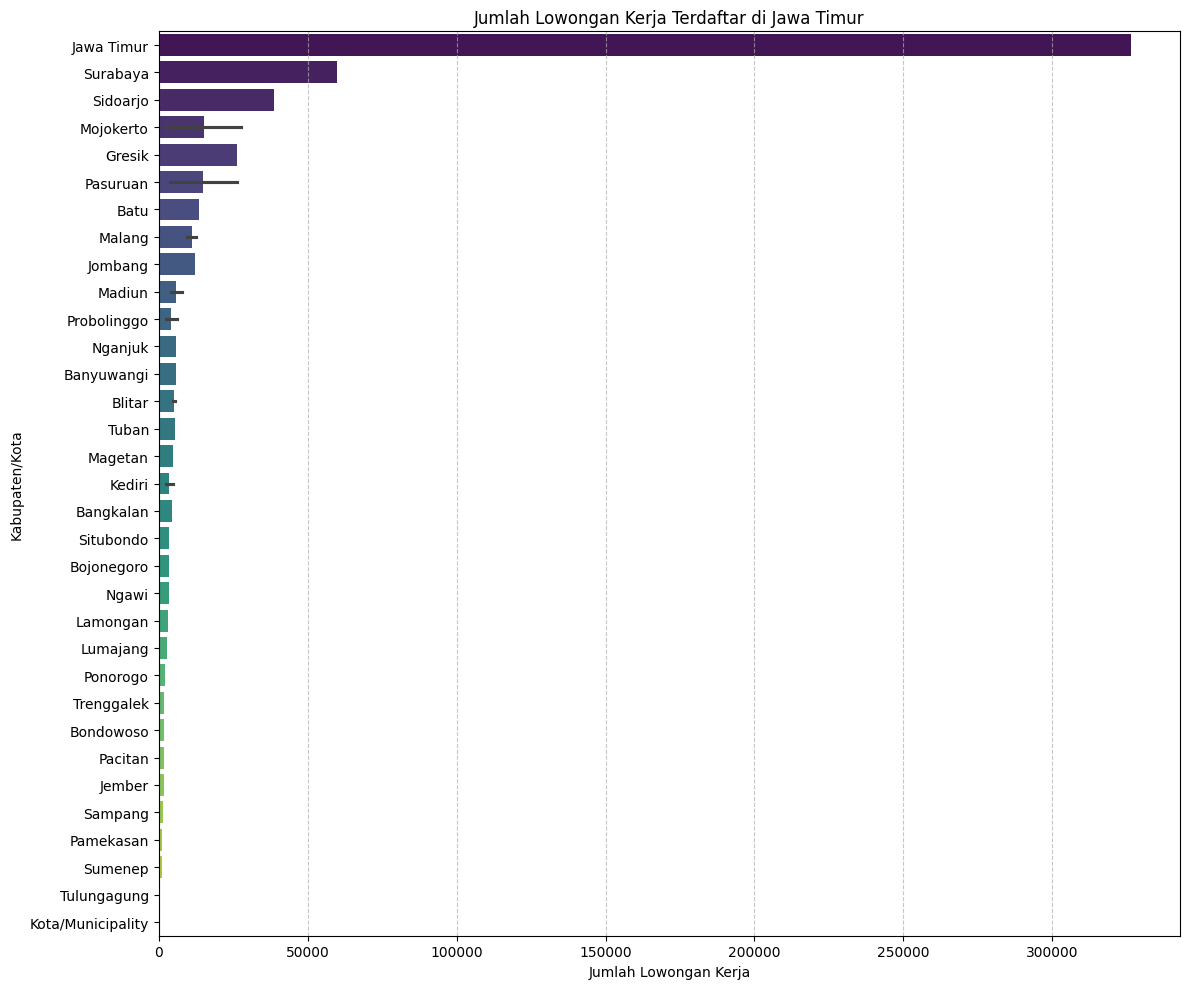

In [19]:
# =========================
# VISUALISASI LOWONGAN KERJA
# =========================

import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# SORTING DATA
# =========================

df_lowongan_sorted = df_lowongan.sort_values(
    by='Total',
    ascending=False
)

# =========================
# MEMBUAT BAR CHART
# =========================

plt.figure(figsize=(12, 10))

sns.barplot(
    data=df_lowongan_sorted,
    x='Total',
    y='Wilayah',
    palette='viridis'
)

# =========================
# JUDUL DAN LABEL
# =========================

plt.title(
    'Jumlah Lowongan Kerja Terdaftar di Jawa Timur'
)

plt.xlabel(
    'Jumlah Lowongan Kerja'
)

plt.ylabel(
    'Kabupaten/Kota'
)

# =========================
# GRID
# =========================

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.7
)

plt.tight_layout()

# =========================
# TAMPILKAN GRAFIK
# =========================

plt.show()

# 11.1 Visualisasi Berdasarkan Jenis Wilayah

Visualisasi ini digunakan untuk membandingkan jumlah lowongan kerja berdasarkan jenis wilayah, yaitu Kabupaten dan Kota.

Selain itu, visualisasi menampilkan 10 wilayah dengan jumlah lowongan kerja tertinggi di Jawa Timur.

,Wilayah,Laki_Laki,Perempuan,Total,Jenis_Wilayah
42,Jawa Timur,171432.0,155073.0,326505.0,Kabupaten
40,Surabaya,29815.0,30202.0,60017.0,Kabupaten
17,Sidoarjo,22053.0,16525.0,38578.0,Kabupaten
18,Mojokerto,13850.0,13867.0,27717.0,Kabupaten
27,Gresik,13657.0,12689.0,26346.0,Kabupaten
16,Pasuruan,13740.0,12472.0,26212.0,Kabupaten
41,Batu,6834.0,6562.0,13396.0,Kabupaten
9,Malang,6481.0,6128.0,12609.0,Kabupaten
19,Jombang,6221.0,5838.0,12059.0,Kabupaten
35,Malang,6608.0,2928.0,9536.0,Kabupaten


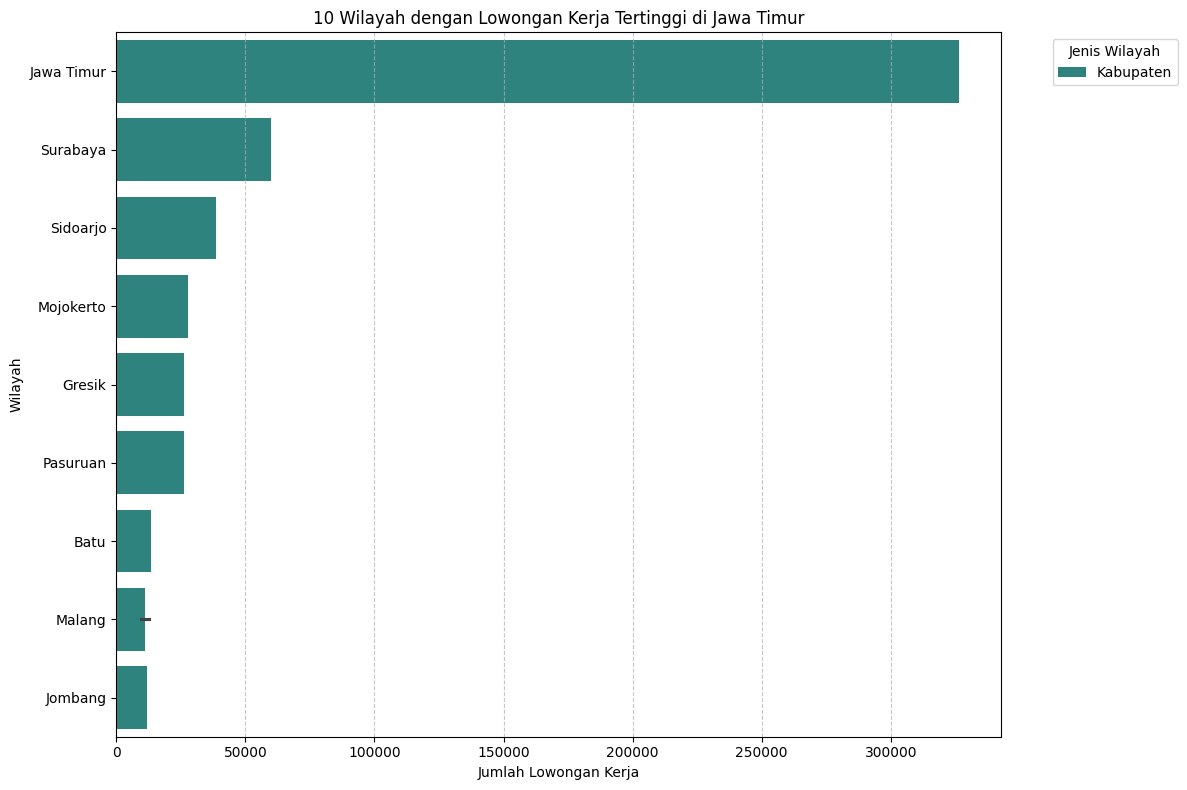

In [20]:
# =========================
# MENAMBAHKAN JENIS WILAYAH
# =========================

df_lowongan['Jenis_Wilayah'] = df_lowongan['Wilayah'].apply(
    lambda x: 'Kota'
    if 'Kota' in str(x)
    else 'Kabupaten'
)

# =========================
# TOP 10 LOWONGAN TERTINGGI
# =========================

top_10_lowongan = df_lowongan.sort_values(
    by='Total',
    ascending=False
).head(10)

# Menampilkan data
display(top_10_lowongan)

# =========================
# MEMBUAT VISUALISASI
# =========================

plt.figure(figsize=(12, 8))

sns.barplot(
    data=top_10_lowongan,
    x='Total',
    y='Wilayah',
    hue='Jenis_Wilayah',
    palette='viridis'
)

# =========================
# JUDUL DAN LABEL
# =========================

plt.title(
    '10 Wilayah dengan Lowongan Kerja Tertinggi di Jawa Timur'
)

plt.xlabel(
    'Jumlah Lowongan Kerja'
)

plt.ylabel(
    'Wilayah'
)

# =========================
# LEGENDA
# =========================

plt.legend(
    title='Jenis Wilayah',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

# =========================
# GRID
# =========================

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.7
)

plt.tight_layout()

# =========================
# MENAMPILKAN GRAFIK
# =========================

plt.show()

# 12. Heatmap Lowongan Kerja Jawa Timur

Heatmap digunakan untuk memvisualisasikan persebaran jumlah lowongan kerja secara geografis di wilayah Jawa Timur.

Semakin terang warna heatmap, maka semakin tinggi jumlah lowongan kerja pada wilayah tersebut.

In [21]:
# =========================
# HEATMAP LOWONGAN KERJA
# =========================

import folium
from folium.plugins import HeatMap

# =========================
# RAPIIKAN NAMA WILAYAH
# =========================

df_lowongan['Wilayah'] = df_lowongan['Wilayah'].astype(str)

df_lowongan['Wilayah'] = df_lowongan['Wilayah'].str.replace(
    'Kabupaten ',
    '',
    regex=False
)

# =========================
# KOORDINAT WILAYAH
# =========================

geo_coords = {
    'Pacitan': (-8.19, 111.10),
    'Ponorogo': (-7.87, 111.47),
    'Trenggalek': (-8.05, 111.71),
    'Tulungagung': (-8.06, 111.90),
    'Blitar': (-8.10, 112.16),
    'Kediri': (-7.82, 112.01),
    'Malang': (-7.98, 112.63),
    'Lumajang': (-8.13, 113.22),
    'Jember': (-8.17, 113.70),
    'Banyuwangi': (-8.22, 114.36),
    'Bondowoso': (-7.91, 113.82),
    'Situbondo': (-7.70, 114.02),
    'Probolinggo': (-7.75, 113.22),
    'Pasuruan': (-7.64, 112.90),
    'Sidoarjo': (-7.45, 112.72),
    'Mojokerto': (-7.47, 112.43),
    'Jombang': (-7.55, 112.23),
    'Nganjuk': (-7.60, 111.90),
    'Madiun': (-7.63, 111.52),
    'Magetan': (-7.65, 111.33),
    'Ngawi': (-7.40, 111.45),
    'Bojonegoro': (-7.15, 111.88),
    'Tuban': (-6.89, 112.05),
    'Lamongan': (-7.12, 112.42),
    'Gresik': (-7.16, 112.65),
    'Bangkalan': (-7.05, 112.93),
    'Sampang': (-7.19, 113.24),
    'Pamekasan': (-7.16, 113.47),
    'Sumenep': (-7.01, 113.86),
    'Kota Kediri': (-7.82, 112.01),
    'Kota Blitar': (-8.10, 112.15),
    'Kota Malang': (-7.98, 112.63),
    'Kota Probolinggo': (-7.75, 113.21),
    'Kota Pasuruan': (-7.64, 112.91),
    'Kota Mojokerto': (-7.47, 112.44),
    'Kota Madiun': (-7.63, 111.52),
    'Kota Surabaya': (-7.25, 112.75),
    'Kota Batu': (-7.87, 112.52)
}

# =========================
# MEMBUAT PETA
# =========================

m = folium.Map(
    location=[-7.7, 112.5],
    zoom_start=8,
    tiles='CartoDB positron'
)

heat_data = []

# =========================
# MEMBACA DATA
# =========================

for _, row in df_lowongan.iterrows():

    wilayah = row['Wilayah']
    total = row['Total']

    # Cek wilayah pada koordinat
    if wilayah in geo_coords:

        lat, lon = geo_coords[wilayah]

        # Menambahkan data heatmap
        heat_data.append([lat, lon, total])

        # Format angka
        formatted_total = f"{int(total):,}".replace(',', '.')

        # =========================
        # MENAMBAHKAN MARKER
        # =========================

        folium.CircleMarker(
            location=[lat, lon],
            radius=7,
            color='blue',
            fill=True,
            fill_color='blue',
            fill_opacity=0.4,

            tooltip=f"""
            <b>{wilayah}</b><br>
            Total Lowongan: {formatted_total}
            """,

            popup=f"""
            <b>{wilayah}</b><br>
            Total Lowongan Kerja:
            {formatted_total}
            """
        ).add_to(m)

# =========================
# MENAMBAHKAN HEATMAP
# =========================

HeatMap(
    heat_data,
    radius=30,
    blur=20,
    min_opacity=0.4
).add_to(m)

# =========================
# MENAMPILKAN PETA
# =========================

m

# 13. Analisis Lowongan Kerja Jawa Timur

Analisis dilakukan untuk mengetahui:
- wilayah dengan jumlah lowongan kerja tertinggi
- wilayah dengan jumlah lowongan kerja terendah
- rata-rata jumlah lowongan kerja di Jawa Timur

In [22]:
# =========================
# ANALISIS LOWONGAN KERJA
# =========================

# Wilayah dengan lowongan tertinggi
tertinggi = df_lowongan.loc[
    df_lowongan['Total'].idxmax()
]

# Wilayah dengan lowongan terendah
terendah = df_lowongan.loc[
    df_lowongan['Total'].idxmin()
]

# Menghitung rata-rata
rata_rata = df_lowongan['Total'].mean()

# =========================
# OUTPUT ANALISIS
# =========================

print(
    "===== ANALISIS LOWONGAN KERJA JAWA TIMUR =====\n"
)

print(
    f"Wilayah dengan lowongan tertinggi : "
    f"{tertinggi['Wilayah']} "
    f"({int(tertinggi['Total'])})"
)

print(
    f"Wilayah dengan lowongan terendah : "
    f"{terendah['Wilayah']} "
    f"({int(terendah['Total'])})"
)

print(
    f"Rata-rata lowongan kerja : "
    f"{rata_rata:.0f}"
)

===== ANALISIS LOWONGAN KERJA JAWA TIMUR =====

Wilayah dengan lowongan tertinggi : Jawa Timur (326505)
Wilayah dengan lowongan terendah : Tulungagung (413)
Rata-rata lowongan kerja : 16744


Wilayah dengan pusat ekonomi lebih besar cenderung memiliki jumlah lowongan kerja yang lebih tinggi dibanding daerah lain

# 14. Kesimpulan

Berdasarkan hasil visualisasi dan analisis data dapat disimpulkan bahwa:

1. Persebaran lowongan kerja di Jawa Timur tidak merata dan cenderung lebih tinggi pada wilayah perkotaan.

2. Nilai Indeks Ketimpangan Gender (IKG) di Jawa Barat menunjukkan adanya perbedaan tingkat ketimpangan antar wilayah.

3. Visualisasi heatmap membantu menunjukkan persebaran data statistik secara geografis sehingga lebih mudah dipahami dan dianalisis.

4. Penggunaan Python, Google Colab, dan Folium mempermudah proses pengolahan data statistik menjadi visualisasi interaktif.